# CreditRisk+ em 24 safras de crédito PF no Brasil

Este estudo simula uma carteira bancária **sintética e madura** com cartão de crédito e crédito pessoal parcelado. Na abertura, o estoque é reconstruído com 180 meses de safras históricas e uma cauda agregada de cartões mais antigos. Seguem-se 12 meses de *burn-in* e 24 safras mensais reportadas, todas acompanhadas até o MOB 60. O CreditRisk+ é aplicado (i) a cada nova safra na originação e (ii) aos 24 fechamentos mensais reportados da carteira ativa.

Objetivos: acompanhar exposição, perda esperada (EL), volatilidade, VaR 95%/99%/99,9%, capital econômico, composição por produto, defaults realizados e curvas de vintage por MOB (*months on book*). Toda aleatoriedade usa semente fixa; já o CreditRisk+ é analítico e determinístico.

## Fontes, escopo e interpretação

O cenário usa apenas âncoras de plausibilidade, não pretende reproduzir uma instituição específica. O Banco Central define inadimplência dessas modalidades como saldo com parcela em atraso superior a 90 dias nas séries de [cartão de crédito total (SGS 21129)](https://dadosabertos.bcb.gov.br/dataset/21129-inadimplencia-da-carteira-de-credito-com-recursos-livres---pessoas-fisicas---cartao-de-credit) e [crédito pessoal não consignado (SGS 21114)](https://dadosabertos.bcb.gov.br/dataset/21114-inadimplencia-da-carteira-de-credito-com-recursos-livres---pessoas-fisicas---credito-pessoal-). O [Relatório de Economia Bancária 2023](https://www.bcb.gov.br/content/publicacoes/relatorioeconomiabancaria/reb2023p.pdf) documenta a sensibilidade do crédito livre PF a juros, endividamento, concessões e baixas para prejuízo.

As PDs, LGDs, volumes, crescimento e choque abaixo são **hipóteses explícitas do cenário**. Eles não são estimativas extraídas diretamente dessas séries e não devem ser usados para decisão real sem calibração, validação temporal e governança. O horizonte da PD e da distribuição CreditRisk+ é de 12 meses; defaults realizados mensais usam a taxa marginal equivalente. A maturidade é verificada por controles de nível, mix, risco e distribuição por idade antes do período reportado.

In [1]:
# Imports e configuração reprodutível.
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from creditriskplus.retail import (
    RetailSimulationConfig,
    SECTOR_COLUMNS,
    simulate_retail_portfolio,
    validate_portfolio_regime,
    run_creditriskplus_over_time,
    run_creditriskplus_by_cohort,
    vintage_default_curves,
)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')

config = RetailSimulationConfig(
    reporting_start='2023-01-01',
    reporting_months=24,
    vintage_performance_months=60,
    backbook_months=180,
    burn_in_months=12,
    annual_origination_growth=0.05,
    shock_start_month=6,
    seed=20260808,
    unit_size=250.0,
)
config

RetailSimulationConfig(reporting_start='2023-01-01', reporting_months=24, vintage_performance_months=60, backbook_months=180, burn_in_months=12, seed=20260808, average_monthly_card_originations=150, average_monthly_installment_originations=110, annual_origination_growth=0.05, shock_start_month=6, unit_size=250.0, tail_tolerance=1e-08, max_pre_report_level_change=0.08, max_pre_report_el_rate_change=0.003, max_pre_report_mix_change=0.03, max_pre_report_age_tv=0.04)

## Construção metodológica

Cada linha representa um pool homogêneo por safra, produto e faixa de risco. `obligor_count` é a multiplicidade: no CreditRisk+, multiplicar as contribuições de $\varepsilon_A$, $\mu_k$ e $\sigma_k$ pelo número de contratos é exatamente equivalente a repetir os contratos individuais.

- **Cartão:** EAD cresce nos primeiros meses com ativação/utilização e aumenta moderadamente sob estresse; não há amortização contratual.
- **Parcelado:** saldo inicial maior e amortização até 24–30 meses; saídas antecipadas e defaults reduzem contratos ativos.
- **Backbook maduro:** 180 safras históricas são sobrevividas até a abertura; cartões ainda mais antigos, já no platô de EAD e seasoning, formam um pool de cauda que preserva o estoque residual.
- **Regime e maturação:** 12 meses de burn-in precedem o reporte; as 24 safras selecionadas continuam observadas até o MOB 60, sem ampliar a janela de métricas CreditRisk+.
- **Cenário:** crescimento comercial de 5% a.a. e choque são ancorados no início reportado, não no tamanho do histórico ou da janela de performance.
- **Risco:** quatro faixas A–D, seasoning por MOB, PD de 12 meses e choque macro transitório; a oferta se contrai e o underwriting fica mais seletivo durante o choque.
- **Setores:** 15% específico (variância zero, A12.3), 45% macro e 40% do produto. Os pesos somam 100% por pool.
- **LGD:** 85% no cartão e 78% no parcelado; recuperações entram reduzindo a exposição antes do banding.

A unidade de R$ 250 mantém até 100 bandas para as maiores exposições individuais. A EL original é preservada exatamente pelo ajuste de PD das equações 11–13; o efeito residual do banding recai sobretudo sobre a variância.

In [2]:
# Simula sequencialmente originações, defaults, saídas e saldos.
panel = simulate_retail_portfolio(config)

assert panel['observation_month'].nunique() == config.n_months
assert panel.loc[~panel.opening_backbook, 'cohort_month'].nunique() == config.n_months
assert panel.opening_backbook.any() and panel.backbook_tail.any()
assert np.allclose(panel[list(SECTOR_COLUMNS)].sum(axis=1), 1.0)
assert (panel['obligor_count'] >= 0).all()

print(f'Linhas pool-mês: {len(panel):,}')
print(f'Backbook explícito: {config.backbook_months} meses + cauda madura de cartões')
print(f'Janela dinâmica: {config.burn_in_months} de burn-in + '      f'{config.reporting_months} reportados + '      f'{config.vintage_performance_months} de maturação da última safra')
print(f'Período: {panel.observation_month.min():%m/%Y} a {panel.observation_month.max():%m/%Y}')
display(panel.head(8))

Linhas pool-mês: 79,268
Backbook explícito: 180 meses + cauda madura de cartões
Janela dinâmica: 12 de burn-in + 24 reportados + 60 de maturação da última safra
Período: 01/2022 a 12/2029


,observation_month,cohort_month,mob,product,risk_band,originated_count,obligor_count,ead_per_obligor,pd_12m,std_pd_12m,recovery_rate,realized_defaults,realized_exits,macro_multiplier,opening_backbook,backbook_tail,sector_weight_specific,sector_weight_macro,sector_weight_card,sector_weight_installment
0,2022-01-01,2021-12-01,1,Cartão de crédito,A,47,46,"1,876.6459",0.0091,0.0059,0.1500,0,0,1.0000,True,False,0.1500,0.4500,0.4000,0.0000
1,2022-01-01,2021-12-01,1,Cartão de crédito,B,52,51,"2,580.3881",0.0265,0.0172,0.1500,1,0,1.0000,True,False,0.1500,0.4500,0.4000,0.0000
2,2022-01-01,2021-12-01,1,Cartão de crédito,C,40,39,"3,362.3239",0.0606,0.0394,0.1500,1,0,1.0000,True,False,0.1500,0.4500,0.4000,0.0000
3,2022-01-01,2021-12-01,1,Cartão de crédito,D,20,20,"4,066.0661",0.1363,0.0886,0.1500,0,1,1.0000,True,False,0.1500,0.4500,0.4000,0.0000
4,2022-01-01,2021-12-01,1,Crédito pessoal parcelado,A,31,31,"7,250.0000",0.0123,0.0068,0.2200,0,0,1.0000,True,False,0.1500,0.4500,0.0000,0.4000
5,2022-01-01,2021-12-01,1,Crédito pessoal parcelado,B,46,44,"8,700.0000",0.0309,0.0170,0.2200,0,0,1.0000,True,False,0.1500,0.4500,0.0000,0.4000
6,2022-01-01,2021-12-01,1,Crédito pessoal parcelado,C,36,36,"10,111.1111",0.0686,0.0377,0.2200,0,1,1.0000,True,False,0.1500,0.4500,0.0000,0.4000
7,2022-01-01,2021-12-01,1,Crédito pessoal parcelado,D,11,11,"11,500.0000",0.1509,0.0830,0.2200,0,0,1.0000,True,False,0.1500,0.4500,0.0000,0.4000


,valor
annual_ead_change,0.0031
annual_active_change,0.0048
el_rate_change,0.0011
max_product_share_change,0.0029
age_distribution_tv,0.0036
passed,True


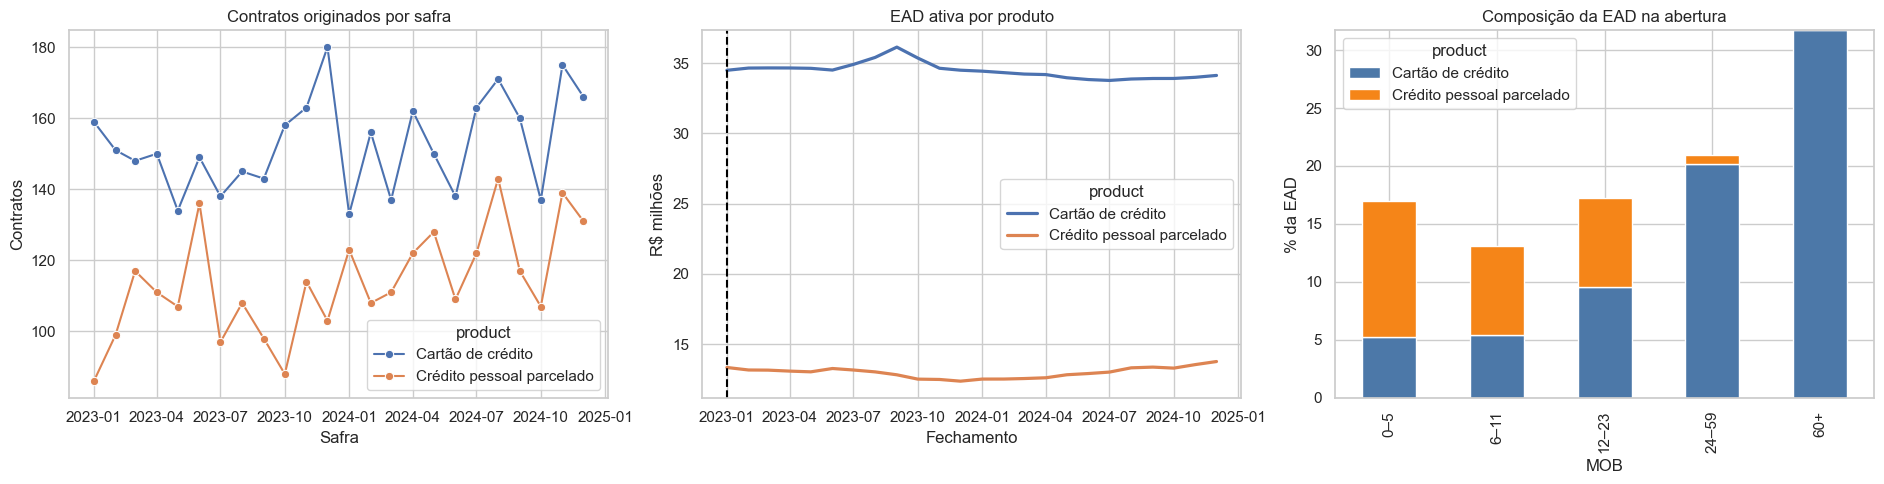

In [3]:
# Valida o regime e mostra originação, estoque e composição etária.
regime = validate_portfolio_regime(panel, config)
display(regime.to_frame('valor'))

report_start = pd.Timestamp(config.reporting_start)
report_end = report_start + pd.DateOffset(months=config.reporting_months-1)
origin = (panel[(panel['mob'] == 0) & (~panel.opening_backbook)
                & panel.cohort_month.between(report_start, report_end)]
          .groupby(['cohort_month', 'product'], as_index=False)
          .agg(contracts=('obligor_count', 'sum')))
panel_plot = panel.assign(pool_ead=panel.obligor_count * panel.ead_per_obligor)
panel_plot = panel_plot[panel_plot.observation_month.between(report_start, report_end)]
ead_product = (panel_plot.groupby(['observation_month', 'product'], as_index=False)
               .agg(gross_ead=('pool_ead', 'sum')))

report_open = panel[panel.observation_month == pd.Timestamp(config.reporting_start)].copy()
report_open['pool_ead'] = report_open.obligor_count * report_open.ead_per_obligor
report_open['Faixa MOB'] = pd.cut(report_open.mob, [-1, 5, 11, 23, 59, np.inf],
                                         labels=['0–5', '6–11', '12–23', '24–59', '60+'])
age_mix = report_open.groupby(['Faixa MOB', 'product'], observed=False).pool_ead.sum().unstack(fill_value=0)
age_mix = age_mix.div(age_mix.sum().sum()) * 100

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
sns.lineplot(data=origin, x='cohort_month', y='contracts', hue='product', marker='o', ax=axes[0])
axes[0].set(title='Contratos originados por safra', xlabel='Safra', ylabel='Contratos')
sns.lineplot(data=ead_product, x='observation_month', y=ead_product.gross_ead/1e6,
             hue='product', linewidth=2.3, ax=axes[1])
axes[1].set(title='EAD ativa por produto', xlabel='Fechamento', ylabel='R$ milhões')
axes[1].axvline(report_start, color='black', ls='--', label='Início do reporte')
age_mix.plot.bar(stacked=True, ax=axes[2], color=['#4c78a8', '#f58518'])
axes[2].set(title='Composição da EAD na abertura', xlabel='MOB', ylabel='% da EAD')
plt.tight_layout(); plt.show()

## Regime e aplicação do CreditRisk+

Antes do cálculo de risco, o início do burn-in é comparado ao início do reporte — meses civis equivalentes — em EAD, clientes ativos, EL/EAD, mix de produto e distribuição de EAD por MOB. A execução é interrompida se os limites de convergência não forem atendidos. As métricas CreditRisk+ permanecem nos 24 fechamentos; somente o acompanhamento de performance prossegue até que todas as 24 safras atinjam MOB 60.

Para cada fechamento e safra, calcula-se a PGF setorial Poisson–Gama e sua PMF pela recursão A10. O domínio começa em $EL+10\sigma$ e é ampliado até a massa omitida ficar abaixo de $10^{-8}$ e comportar o percentil 99,9%. A massa truncada **não é renormalizada**. VaR é o quantil discreto $\min\{nL:F(nL)\ge q\}$; a interpolação do XLS não é usada nos relatórios econômicos.

In [4]:
# 24 fechamentos de uma carteira já madura e 24 novas safras reportadas.
monthly_metrics = run_creditriskplus_over_time(panel, config)
cohort_metrics = run_creditriskplus_by_cohort(panel, config)
vintage_curves = vintage_default_curves(panel, config)

assert len(monthly_metrics) == 24
assert len(cohort_metrics) == 24
assert (vintage_curves.groupby('cohort_month').mob.max() == config.vintage_performance_months).all()
assert monthly_metrics.tail_mass.max() <= config.tail_tolerance
assert cohort_metrics.tail_mass.max() <= config.tail_tolerance
assert (monthly_metrics.var_999 >= monthly_metrics.var_99).all()
assert (monthly_metrics.var_99 >= monthly_metrics.expected_loss).all()

print('Validações concluídas: regime, 24 safras até MOB 60, 24 fechamentos e caudas controladas.')

Validações concluídas: regime, 24 safras até MOB 60, 24 fechamentos e caudas controladas.


In [5]:
# Tabela executiva mensal em R$ milhões.
executive = monthly_metrics.copy()
for column in ['gross_ead', 'expected_loss', 'loss_std', 'var_95', 'var_99',
               'var_999', 'economic_capital_99', 'economic_capital_999']:
    executive[column] /= 1e6
executive = executive.rename(columns={
    'observation_month': 'Fechamento', 'active_obligors': 'Clientes ativos',
    'gross_ead': 'EAD (R$ mi)', 'expected_loss': 'EL (R$ mi)',
    'loss_std': 'Sigma (R$ mi)', 'var_95': 'VaR95 (R$ mi)',
    'var_99': 'VaR99 (R$ mi)', 'var_999': 'VaR99,9 (R$ mi)',
    'economic_capital_99': 'EC99 (R$ mi)',
    'economic_capital_999': 'EC99,9 (R$ mi)', 'tail_mass': 'Massa truncada'
})
executive_view = executive[['Fechamento', 'Clientes ativos', 'EAD (R$ mi)', 'EL (R$ mi)',
                             'VaR99 (R$ mi)', 'VaR99,9 (R$ mi)', 'EC99 (R$ mi)',
                             'Massa truncada']].copy()
numeric_columns = executive_view.columns.difference(['Fechamento'])
executive_view[numeric_columns] = executive_view[numeric_columns].round(4)
display(executive_view)

,Fechamento,Clientes ativos,EAD (R$ mi),EL (R$ mi),VaR99 (R$ mi),"VaR99,9 (R$ mi)",EC99 (R$ mi),Massa truncada
0,2023-01-01,14109,47.8308,2.3494,4.7252,5.8972,2.3759,0.0000
1,2023-02-01,14107,47.8124,2.4116,4.8532,6.0575,2.4417,0.0000
2,2023-03-01,14058,47.8116,2.4546,4.9418,6.1685,2.4872,0.0000
3,2023-04-01,14048,47.7382,2.4638,4.9610,6.1925,2.4972,0.0000
4,2023-05-01,14028,47.6624,2.4447,4.9248,6.1475,2.4800,0.0000
5,2023-06-01,14042,47.7750,2.4037,4.8402,6.0418,2.4366,0.0000
6,2023-07-01,14008,48.0710,2.7200,5.4780,6.8378,2.7580,0.0000
7,2023-08-01,13983,48.4344,3.1179,6.2815,7.8408,3.1636,0.0000
8,2023-09-01,13929,48.9600,3.7522,7.5668,9.4462,3.8146,0.0000
9,2023-10-01,13884,47.8735,3.1821,6.4205,8.0155,3.2384,0.0000


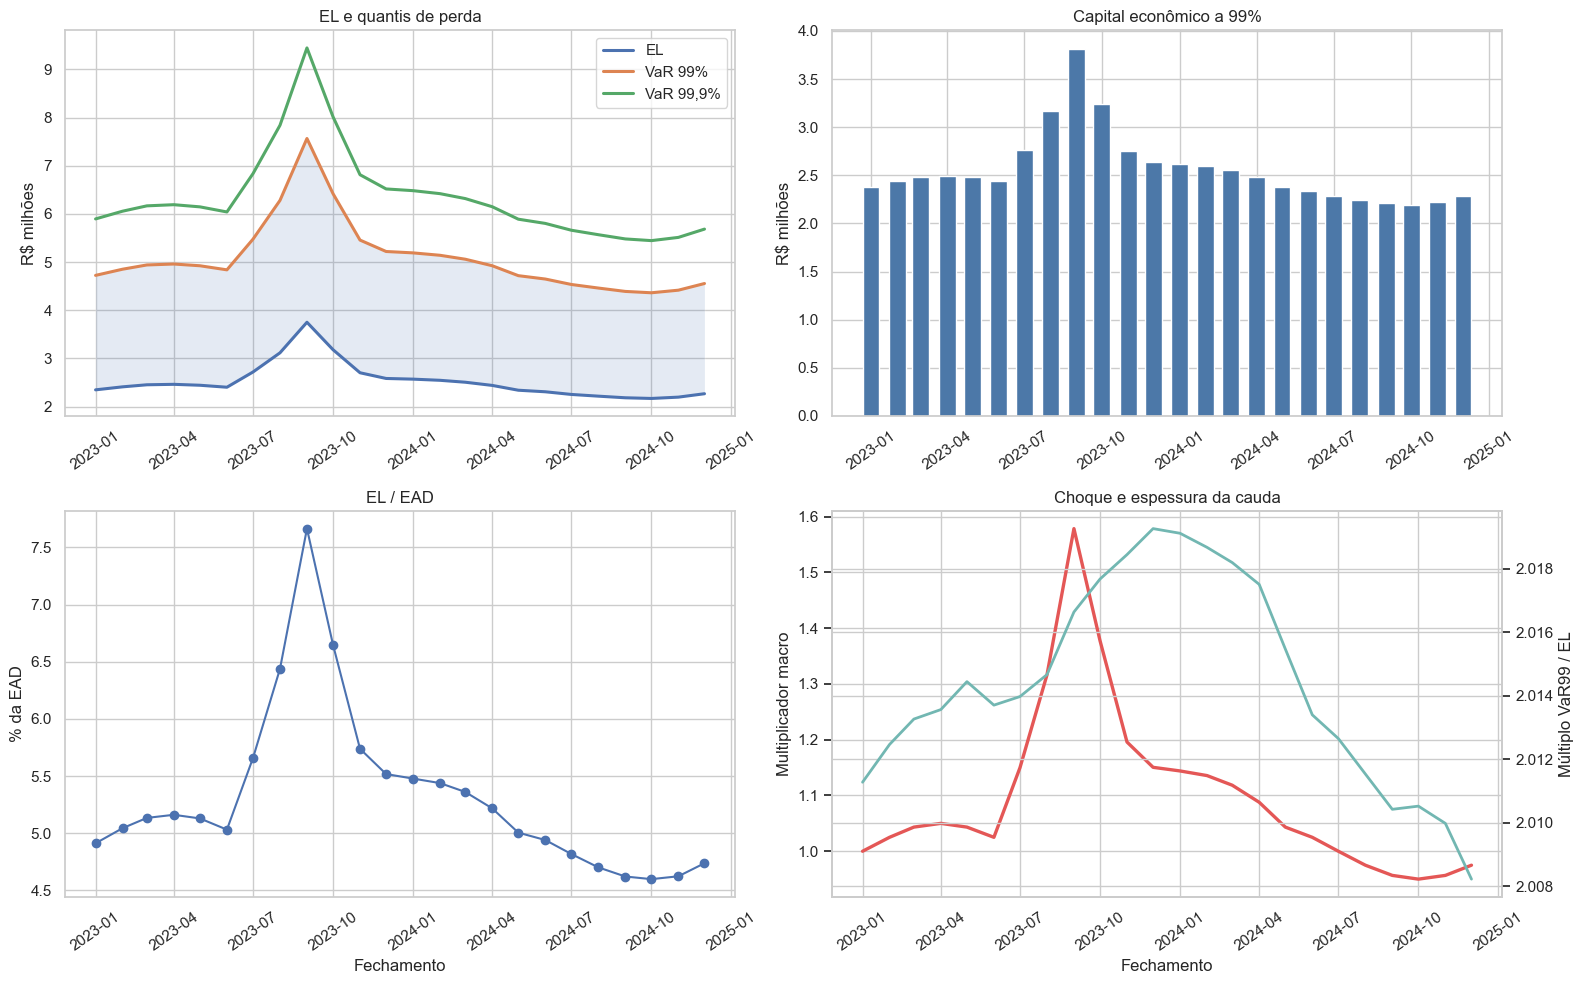

In [6]:
# Evolução temporal dos principais indicadores de risco.
m = monthly_metrics
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes[0, 0].plot(m.observation_month, m.expected_loss/1e6, label='EL', lw=2.2)
axes[0, 0].plot(m.observation_month, m.var_99/1e6, label='VaR 99%', lw=2.2)
axes[0, 0].plot(m.observation_month, m.var_999/1e6, label='VaR 99,9%', lw=2.2)
axes[0, 0].fill_between(m.observation_month, m.expected_loss/1e6, m.var_99/1e6, alpha=.15)
axes[0, 0].set(title='EL e quantis de perda', ylabel='R$ milhões'); axes[0, 0].legend()

axes[0, 1].bar(m.observation_month, m.economic_capital_99/1e6, width=20, color='#4c78a8')
axes[0, 1].set(title='Capital econômico a 99%', ylabel='R$ milhões')

axes[1, 0].plot(m.observation_month, 100*m.expected_loss/m.gross_ead, marker='o')
axes[1, 0].set(title='EL / EAD', ylabel='% da EAD', xlabel='Fechamento')

axes[1, 1].plot(m.observation_month, m.macro_multiplier, color='#e45756', lw=2.4, label='Fator macro')
ax2 = axes[1, 1].twinx()
ax2.plot(m.observation_month, m.var_99/m.expected_loss, color='#72b7b2', lw=2, label='VaR99 / EL')
axes[1, 1].set(title='Choque e espessura da cauda', ylabel='Multiplicador macro', xlabel='Fechamento')
ax2.set_ylabel('Múltiplo VaR99 / EL')
for ax in axes.flat: ax.tick_params(axis='x', rotation=35)
plt.tight_layout(); plt.show()

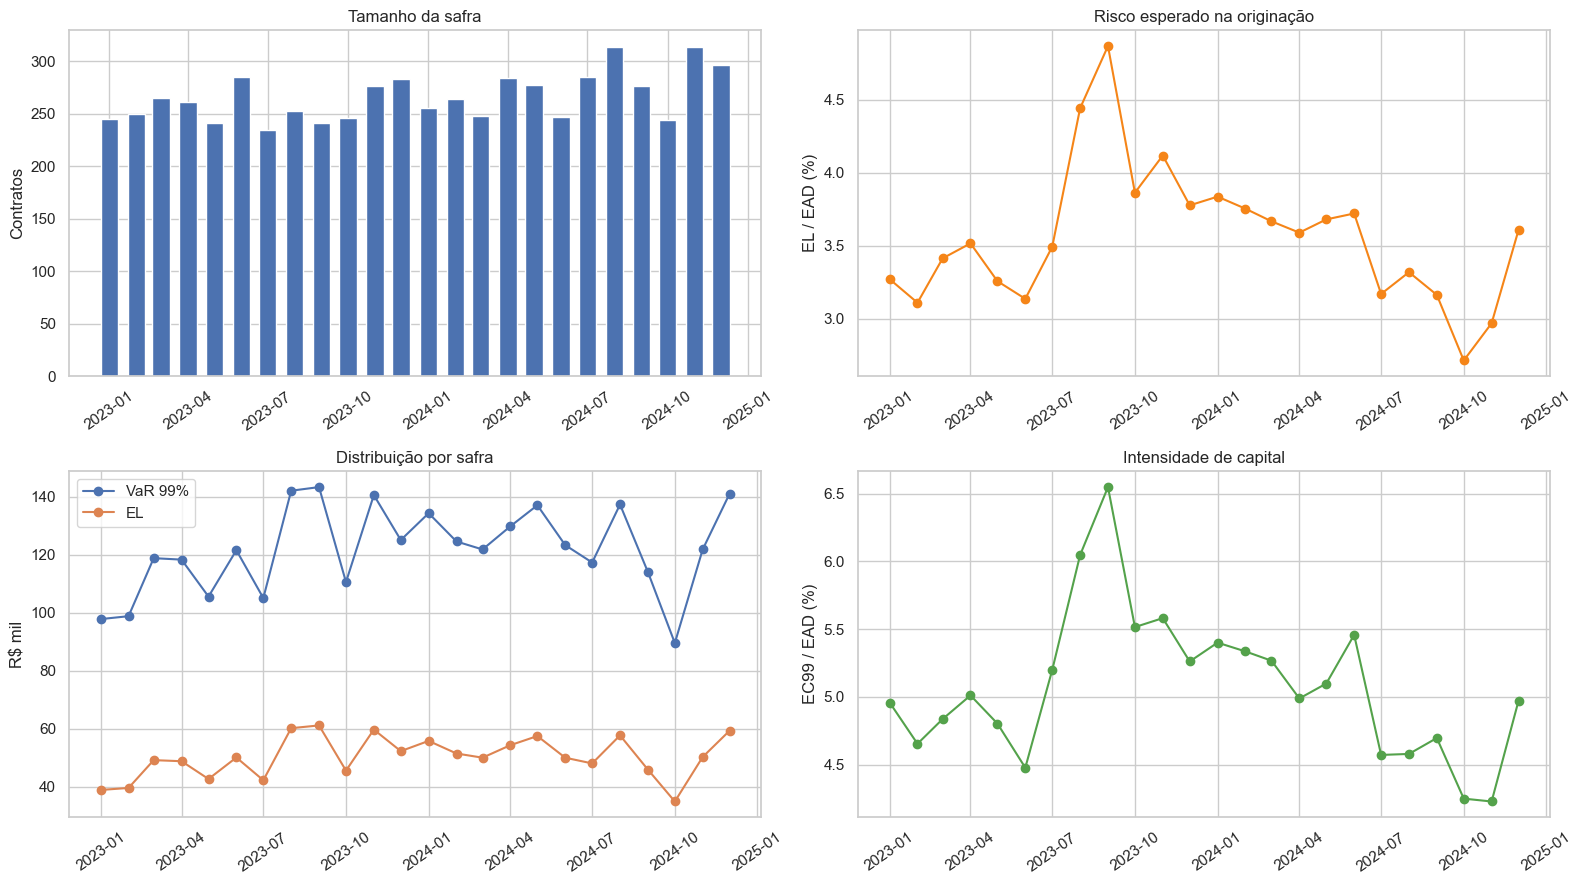

In [7]:
# CreditRisk+ aplicado isoladamente a cada uma das 24 safras reportadas.
c = cohort_metrics
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes[0, 0].bar(c.cohort_month, c.originated_obligors, width=20)
axes[0, 0].set(title='Tamanho da safra', ylabel='Contratos')
axes[0, 1].plot(c.cohort_month, 100*c.expected_loss/c.origination_ead, marker='o', color='#f58518')
axes[0, 1].set(title='Risco esperado na originação', ylabel='EL / EAD (%)')
axes[1, 0].plot(c.cohort_month, c.var_99/1e3, marker='o', label='VaR 99%')
axes[1, 0].plot(c.cohort_month, c.expected_loss/1e3, marker='o', label='EL')
axes[1, 0].set(title='Distribuição por safra', ylabel='R$ mil'); axes[1, 0].legend()
axes[1, 1].plot(c.cohort_month, c.economic_capital_99/c.origination_ead*100, marker='o', color='#54a24b')
axes[1, 1].set(title='Intensidade de capital', ylabel='EC99 / EAD (%)')
for ax in axes.flat: ax.tick_params(axis='x', rotation=35)
plt.tight_layout(); plt.show()

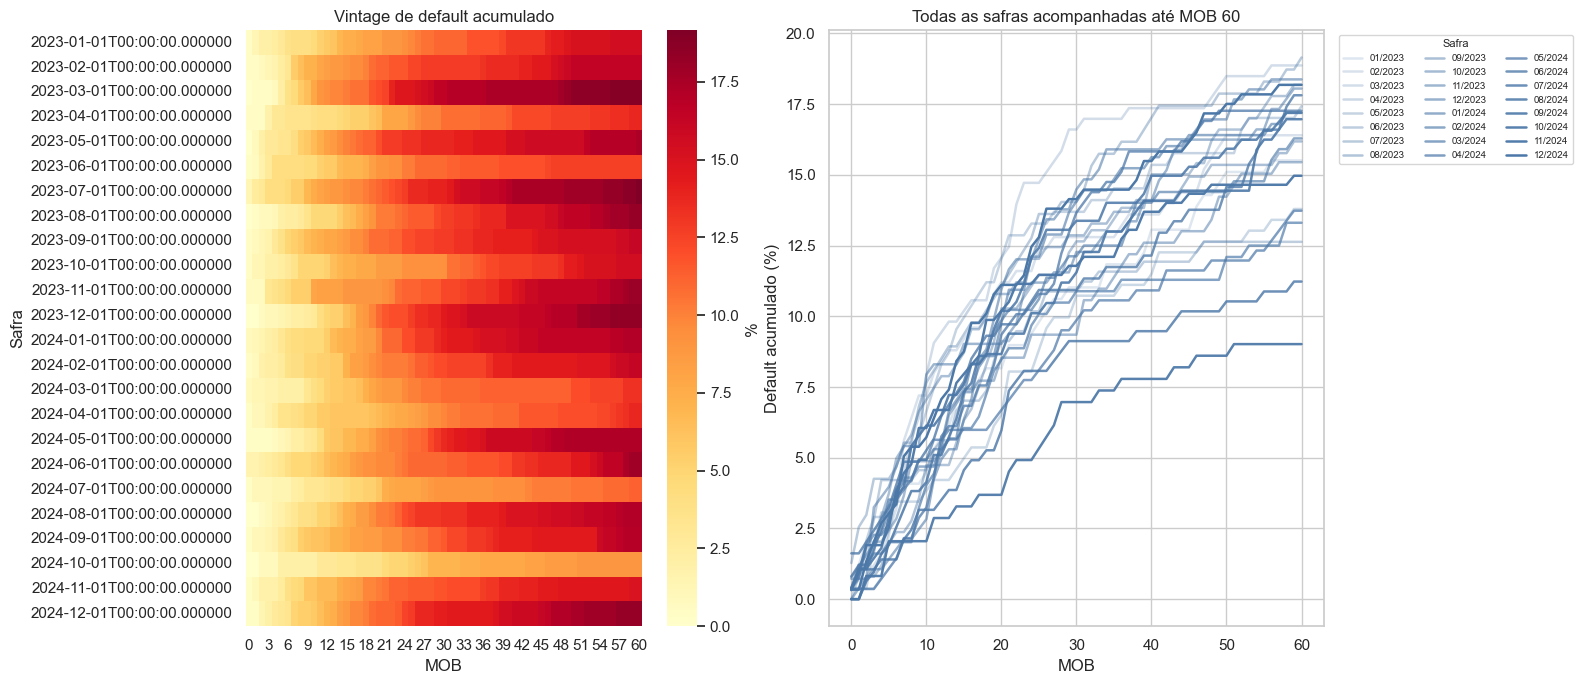

In [8]:
# Curvas de vintage: taxa de default realizada acumulada por idade da safra.
pivot = vintage_curves.pivot(index='cohort_month', columns='mob', values='cumulative_default_rate')
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.heatmap(pivot*100, cmap='YlOrRd', mask=pivot.isna(), ax=axes[0], cbar_kws={'label': '%'})
axes[0].set(title='Vintage de default acumulado', xlabel='MOB', ylabel='Safra')

# Todas as safras usam a mesma cor; a opacidade cresce das antigas para as novas.
alphas = np.linspace(0.18, 1.0, len(pivot.index))
for cohort, alpha in zip(pivot.index, alphas):
    curve = pivot.loc[cohort].dropna()
    axes[1].plot(curve.index, curve.values*100, color='#4c78a8', alpha=alpha,
                 linewidth=1.8, label=f'{cohort:%m/%Y}')
axes[1].set(title='Todas as safras acompanhadas até MOB 60', xlabel='MOB', ylabel='Default acumulado (%)')
axes[1].legend(title='Safra', ncol=3, fontsize=7, title_fontsize=8,
               loc='upper left', bbox_to_anchor=(1.02, 1.0))
plt.tight_layout(); plt.show()

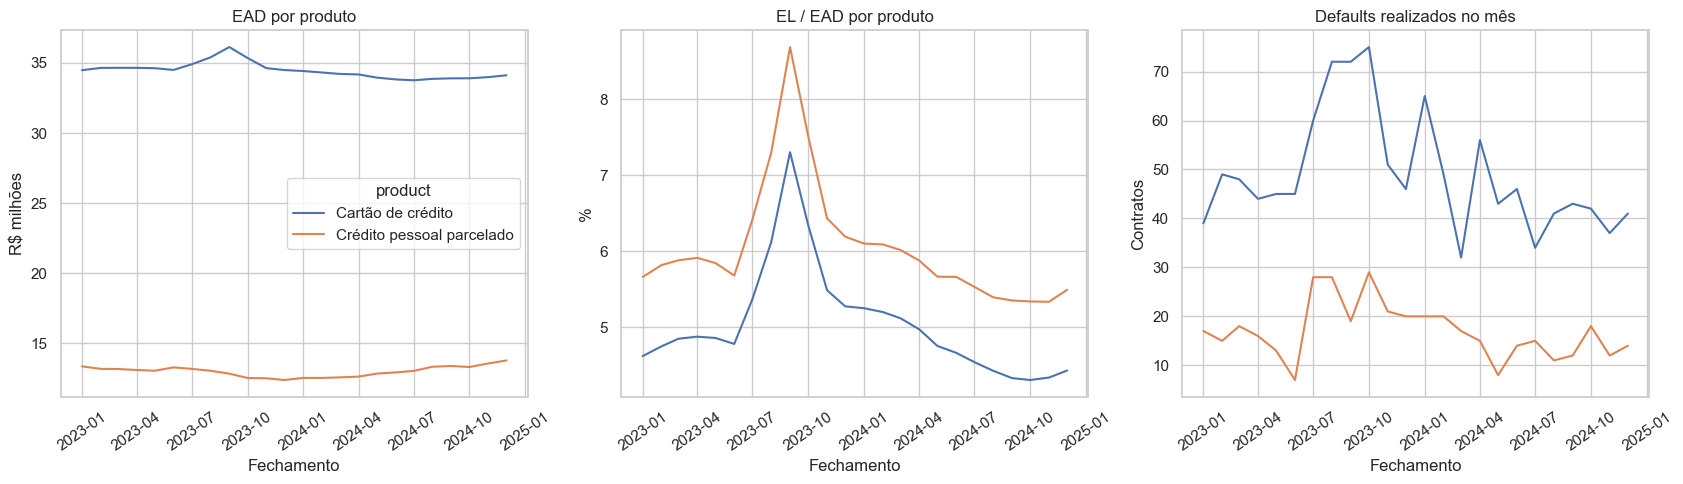

,EAD_medio_R_mi,EL_media_R_mi,taxa_EL_media,defaults
product,,,,
Cartão de crédito,34.4558,1.7405,0.0504,1175
Crédito pessoal parcelado,12.9909,0.7846,0.0605,407


In [9]:
# Decomposição contábil de EAD e EL por produto nos 24 fechamentos reportados.
reported = panel[panel.observation_month.isin(monthly_metrics.observation_month)].copy()
reported['gross_ead_pool'] = reported.obligor_count * reported.ead_per_obligor
reported['el_pool'] = (reported.gross_ead_pool * (1-reported.recovery_rate) * reported.pd_12m)
product_time = (reported.groupby(['observation_month', 'product'], as_index=False)
                .agg(gross_ead=('gross_ead_pool', 'sum'), expected_loss=('el_pool', 'sum'),
                     defaults=('realized_defaults', 'sum')))
product_time['el_rate'] = product_time.expected_loss/product_time.gross_ead

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
sns.lineplot(data=product_time, x='observation_month', y=product_time.gross_ead/1e6,
             hue='product', ax=axes[0])
axes[0].set(title='EAD por produto', ylabel='R$ milhões', xlabel='Fechamento')
sns.lineplot(data=product_time, x='observation_month', y=product_time.el_rate*100,
             hue='product', ax=axes[1], legend=False)
axes[1].set(title='EL / EAD por produto', ylabel='%', xlabel='Fechamento')
sns.lineplot(data=product_time, x='observation_month', y='defaults', hue='product',
             ax=axes[2], legend=False)
axes[2].set(title='Defaults realizados no mês', ylabel='Contratos', xlabel='Fechamento')
for ax in axes: ax.tick_params(axis='x', rotation=35)
plt.tight_layout(); plt.show()

display(product_time.groupby('product').agg(
    EAD_medio=('gross_ead', 'mean'), EL_media=('expected_loss', 'mean'),
    taxa_EL_media=('el_rate', 'mean'), defaults=('defaults', 'sum')
).assign(EAD_medio_R_mi=lambda x: x.EAD_medio/1e6,
         EL_media_R_mi=lambda x: x.EL_media/1e6)
  [['EAD_medio_R_mi', 'EL_media_R_mi', 'taxa_EL_media', 'defaults']].round(4))

In [10]:
# Diagnósticos e leitura automática dos principais movimentos.
peak = monthly_metrics.loc[monthly_metrics.economic_capital_99.idxmax()]
start = monthly_metrics.iloc[0]
end = monthly_metrics.iloc[-1]
worst_cohort = cohort_metrics.loc[(cohort_metrics.expected_loss/cohort_metrics.origination_ead).idxmax()]

diagnostics = pd.Series({
    'Mudança anual da EAD antes do reporte': regime['annual_ead_change'],
    'Distância TV da distribuição por idade': regime['age_distribution_tv'],
    'Maior massa truncada': monthly_metrics.tail_mass.max(),
    'Menor massa acumulada': 1-monthly_metrics.tail_mass.max(),
    'Crescimento da EAD (24 meses)': end.gross_ead/start.gross_ead-1,
    'Variação da EL': end.expected_loss/start.expected_loss-1,
    'EC99 máximo / EAD': peak.economic_capital_99/peak.gross_ead,
})
display(diagnostics.to_frame('valor'))
print(f'Pico de capital: {peak.observation_month:%m/%Y}, EC99 = R$ {peak.economic_capital_99/1e6:.2f} mi.')
print(f'Safra de maior EL/EAD: {worst_cohort.cohort_month:%m/%Y}, '      f'{100*worst_cohort.expected_loss/worst_cohort.origination_ead:.2f}%.')
print('A massa truncada máxima permanece muito abaixo da tolerância; os quantis não dependem de renormalização.')

,valor
Mudança anual da EAD antes do reporte,0.0031
Distância TV da distribuição por idade,0.0036
Maior massa truncada,0.0000
Menor massa acumulada,1.0000
Crescimento da EAD (24 meses),0.0012
Variação da EL,-0.0343
EC99 máximo / EAD,0.0779


Pico de capital: 09/2023, EC99 = R$ 3.81 mi.
Safra de maior EL/EAD: 09/2023, 4.87%.
A massa truncada máxima permanece muito abaixo da tolerância; os quantis não dependem de renormalização.


## Conclusões e limitações

O backbook maduro remove o crescimento artificial causado pela partida em carteira vazia. O acompanhamento comum até MOB 60 elimina a censura desigual entre as curvas de vintage e permite observar a desaceleração do default acumulado. A leitura conjunta passa a separar quatro efeitos observáveis: tendência comercial, mudança do mix, choque macroeconômico e dependência sistemática. Durante o choque, a originação recua e melhora marginalmente de mix, mas as exposições já ativas sofrem aumento de PD e utilização; por isso EL e capital do estoque podem piorar mesmo com underwriting mais conservador nas novas safras. O parcelado amortiza e limita a persistência de EAD, enquanto o cartão mantém exposição aberta e responde mais rapidamente ao estresse.

Limitações materiais: (1) CreditRisk+ usa aproximação Poisson para defaults raros e não modela diretamente migração/cura; (2) fatores Gama são independentes entre setores; (3) EAD, PD e recuperação são pontuais dentro de cada pool; (4) o backbook usa histórico sintético e agrega cartões anteriores a 180 meses somente após EAD e seasoning convergirem; (5) crescimento e choque são cenários, não previsões; (6) VaR não é medida coerente e deve ser complementado por Expected Shortfall, stress testing, backtesting e limites de concentração; (7) para produção seriam necessários calibração em dados internos, tratamento de censura das safras recentes, validação fora da amostra e governança regulatória.